<a href="https://colab.research.google.com/github/monetneva/AFRL-PROJECT/blob/main/Audio_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [16]:
import matplotlib.pyplot as plt
import librosa.display

In [5]:
train_dir = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/Acoustic_train_test/EII_Raw_Ac_Fusion_Data_Train'
test_dir = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/Acoustic_train_test/EII_Raw_Ac_Fusion_Data_Test'
long_audio_path = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/RawAcoustic_EO_IR_Fusion/d301sA2r01p0520210824_1.wav'

In [6]:
def get_label(fname) -> str:
    if 'A2' in fname or 'drone' in fname:
        return 'drone'
    elif 'V1' in fname or 'car' in fname:
        return 'car'
    else:
        return 'unknown'

def extract_features_from_file(file_path, sr=48000):
    y, _ = librosa.load(file_path, sr=sr)
    return extract_features_from_signal(y, sr)

def extract_features_from_signal(y, sr=48000):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
    rms = librosa.feature.rms(y=y).mean()
    zcr = librosa.feature.zero_crossing_rate(y=y).mean()
    return np.hstack([mfccs, chroma, spec_cent, spec_bw, rms, zcr])

In [7]:
train_files = sorted([f for f in os.listdir(train_dir) if f.endswith('.wav')])
X_train = []
y_train = []

In [8]:
for fname in train_files:
    path = os.path.join(train_dir, fname)
    features = extract_features_from_file(path)
    X_train.append(features)
    y_train.append(get_label(fname))

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1599
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [9]:
X_train = np.array(X_train)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

Xtr, Xval, ytr, yval = train_test_split(X_train, y_train_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(Xtr, ytr)

RandomForestClassifier(random_state=42)

In [10]:
print("\nVALIDATION REPORT")
yval_pred = clf.predict(Xval)
print(classification_report(yval, yval_pred, target_names=le.classes_))


VALIDATION REPORT
              precision    recall  f1-score   support

         car       0.97      1.00      0.99        39
       drone       1.00      0.95      0.98        21

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [11]:
test_files = sorted([f for f in os.listdir(test_dir) if f.endswith('.wav')])
X_test = []

for fname in test_files:
    path = os.path.join(test_dir, fname)
    features = extract_features_from_file(path)
    X_test.append(features)

X_test = np.array(X_test)
y_pred = clf.predict(X_test)
predicted_labels = le.inverse_transform(y_pred)

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1599
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [12]:
print("\nPREDICCIONES DE ARCHIVOS DE TEST")
for fname, label in zip(test_files, predicted_labels):
    print(f"{fname} -> {label}")



PREDICCIONES DE ARCHIVOS DE TEST
d301A2r01p05c_0.wav -> drone
d301A2r01p05c_1.wav -> drone
d301A2r01p05c_10.wav -> drone
d301A2r01p05c_11.wav -> drone
d301A2r01p05c_12.wav -> drone
d301A2r01p05c_13.wav -> drone
d301A2r01p05c_14.wav -> drone
d301A2r01p05c_15.wav -> drone
d301A2r01p05c_16.wav -> drone
d301A2r01p05c_17.wav -> drone
d301A2r01p05c_18.wav -> drone
d301A2r01p05c_19.wav -> drone
d301A2r01p05c_2.wav -> drone
d301A2r01p05c_20.wav -> drone
d301A2r01p05c_21.wav -> drone
d301A2r01p05c_22.wav -> drone
d301A2r01p05c_23.wav -> drone
d301A2r01p05c_24.wav -> drone
d301A2r01p05c_25.wav -> drone
d301A2r01p05c_26.wav -> drone
d301A2r01p05c_27.wav -> drone
d301A2r01p05c_28.wav -> drone
d301A2r01p05c_29.wav -> drone
d301A2r01p05c_3.wav -> drone
d301A2r01p05c_4.wav -> drone
d301A2r01p05c_5.wav -> drone
d301A2r01p05c_6.wav -> drone
d301A2r01p05c_7.wav -> drone
d301A2r01p05c_8.wav -> drone
d301A2r01p05c_9.wav -> drone
d301A2r03p03c_0.wav -> drone
d301A2r03p03c_1.wav -> drone
d301A2r03p03c_10.w

In [1]:
def analyze_long_audio(file_path, window_sec=2.0, sr=48000, threshold=0.7):
    y, _ = librosa.load(file_path, sr=sr)
    window_samples = int(window_sec * sr)
    print("\nAnálisis por ventanas de {} segundos".format(window_sec))

    for i in range(0, len(y), window_samples):
        segment = y[i:i+window_samples]
        if len(segment) < window_samples:
            break

        features = extract_features_from_signal(segment, sr=sr)
        proba = clf.predict_proba([features])[0]
        max_prob = np.max(proba)
        pred_index = np.argmax(proba)

        if max_prob < threshold:
            label = "unknown"
        else:
            label = le.inverse_transform([pred_index])[0]

        start_sec = i / sr
        end_sec = (i + window_samples) / sr
        prob_str = ', '.join(["{}: {:.1f}%".format(le.classes_[j], 100 * p) for j, p in enumerate(proba)])

        print("From {:.2f}s to {:.2f}s {} ({})".format(start_sec, end_sec, label, prob_str))



In [29]:
test_path = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/RawAcoustic_EO_IR_Fusion/d301sA2r01p0520210824_1.wav'
analyze_long_audio(test_path)


Análisis por ventanas de 2.0 segundos
From 0.00s to 2.00s unknown (car: 33.0%, drone: 67.0%)
From 2.00s to 4.00s unknown (car: 33.0%, drone: 67.0%)
From 4.00s to 6.00s unknown (car: 34.0%, drone: 66.0%)
From 6.00s to 8.00s unknown (car: 37.0%, drone: 63.0%)
From 8.00s to 10.00s unknown (car: 39.0%, drone: 61.0%)
From 10.00s to 12.00s unknown (car: 68.0%, drone: 32.0%)
From 12.00s to 14.00s unknown (car: 68.0%, drone: 32.0%)
From 14.00s to 16.00s unknown (car: 57.0%, drone: 43.0%)
From 16.00s to 18.00s drone (car: 6.0%, drone: 94.0%)
From 18.00s to 20.00s drone (car: 4.0%, drone: 96.0%)
From 20.00s to 22.00s drone (car: 0.0%, drone: 100.0%)
From 22.00s to 24.00s drone (car: 0.0%, drone: 100.0%)
From 24.00s to 26.00s drone (car: 2.0%, drone: 98.0%)
From 26.00s to 28.00s drone (car: 0.0%, drone: 100.0%)
From 28.00s to 30.00s drone (car: 0.0%, drone: 100.0%)
From 30.00s to 32.00s drone (car: 0.0%, drone: 100.0%)
From 32.00s to 34.00s drone (car: 3.0%, drone: 97.0%)
From 34.00s to 36.00s d

In [24]:
from mpl_toolkits.mplot3d import Axes3D

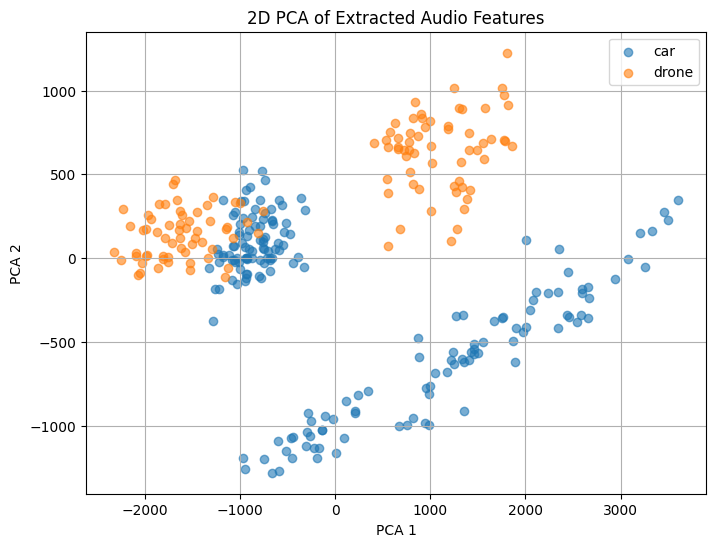

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
for class_idx in np.unique(y_train_encoded):
    plt.scatter(X_proj[y_train_encoded == class_idx, 0],
                X_proj[y_train_encoded == class_idx, 1],
                label=le.inverse_transform([class_idx])[0],
                alpha=0.6)

plt.title("2D PCA of Extracted Audio Features")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


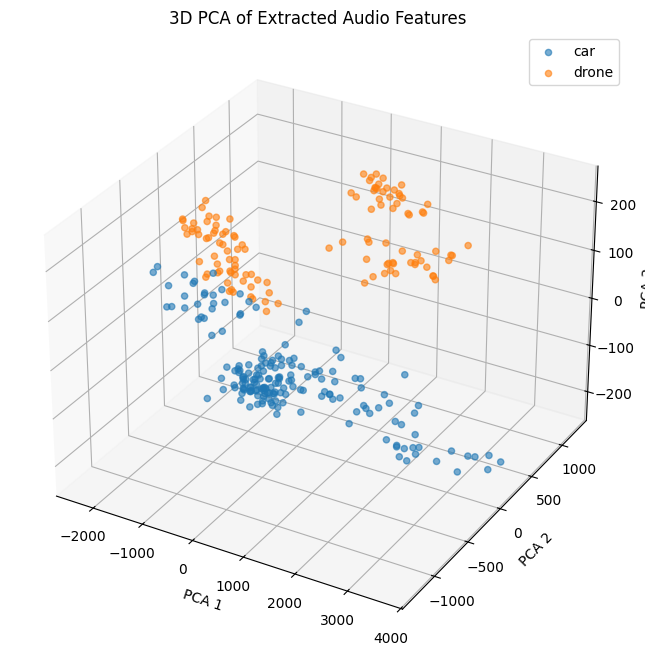

In [27]:
pca = PCA(n_components=3)
X_proj_3d = pca.fit_transform(X_train)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Add a 3D subplot
for class_idx in np.unique(y_train_encoded):
    ax.scatter(X_proj_3d[y_train_encoded == class_idx, 0],
               X_proj_3d[y_train_encoded == class_idx, 1],
               X_proj_3d[y_train_encoded == class_idx, 2],
               label=le.inverse_transform([class_idx])[0],
               alpha=0.6)

ax.set_title("3D PCA of Extracted Audio Features")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.legend()
plt.grid(True)
plt.show()